# Empirical Pipeline: Phantom Labels, NN Training, MM Backtest

This notebook implements the full empirical pipeline:

1. **Part 1: Phantom Label Generation** — Extract phantom-fill labels from empirical KGHM order-flow data
2. **Part 2: Neural Network Training** — Train a fill-probability MLP on the empirical labels
3. **Part 3: Market Maker Backtest** — Backtest ergodic and NN-based market makers on empirical data

In [1]:
import json
import random
import subprocess
import time
import warnings
from pathlib import Path
from typing import List, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import curve_fit, minimize_scalar

from research_core.classes import AnalyseMarket, PhantomLabelConfig, PhantomLabeller, write_day_parquet, write_feature_schema, write_manifest
from research_core.classes.helpers import project_root, resolve_data_path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Empirical Stylized Facts & Market Microstructure

In [2]:
asset = "KGHM"
tick_size = 0.05

db_path = resolve_data_path(f"{asset}_order_flow.sqlite")
am = AnalyseMarket(db_path, tick_size=tick_size)

AnalyseMarket | KGHM_order_flow.sqlite | real data
  Tables: ['fills', 'mo_orders', 'orders']


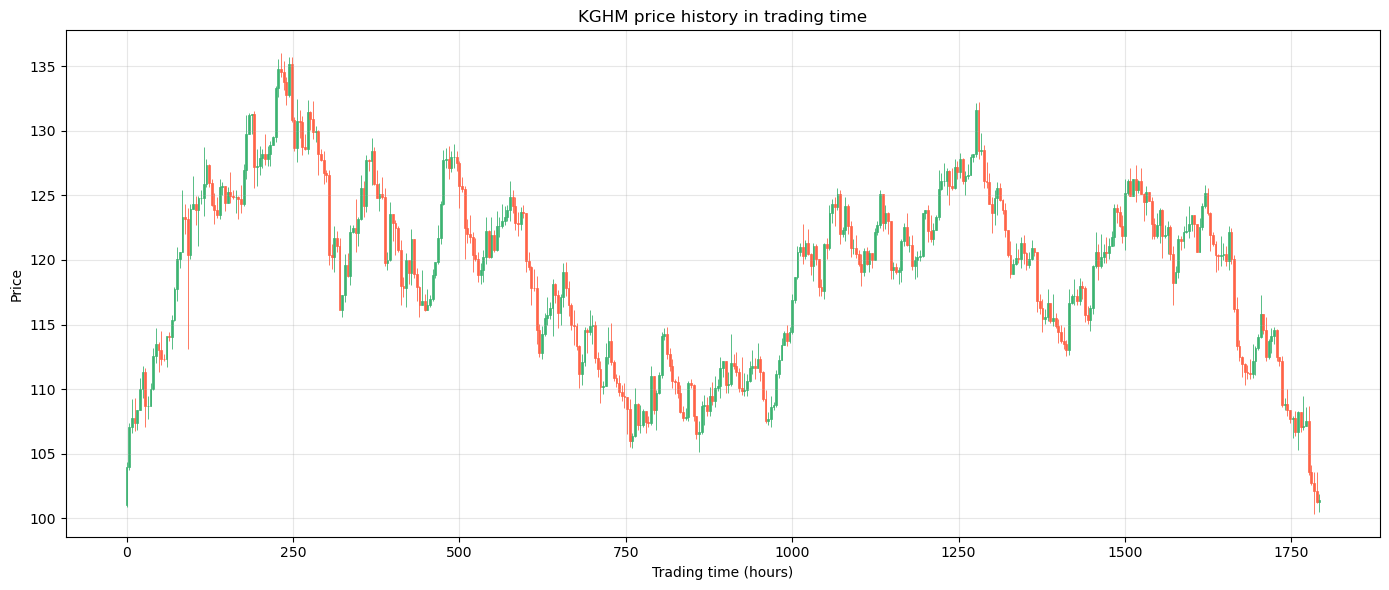

In [3]:
am.plot_candlestick(timeframe=14400, title="KGHM price history in trading time")

Full sign series length: 612,612 MOs,  buy fraction: 0.517
Power-law exponent:  γ = 0.5445   (ρ(ℓ) ~ ℓ^{-0.5445})


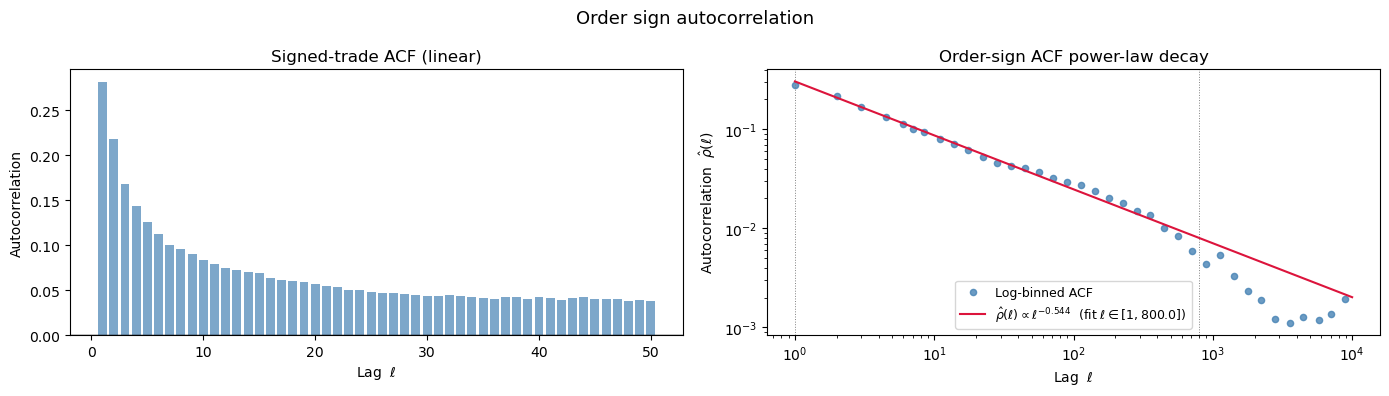

In [3]:
am.stylized_order_sign_autocorrelation(cap=800)

Propagator data (612,612 MOs, 229 days):
  R(1) check: 207,110 pos (33.8%), 367,936 zero (60.1%), 37,337 neg (6.1%)
  Among price-moving: 84.7% positive (expect >> 50%)
  Mean R(1): 0.018552


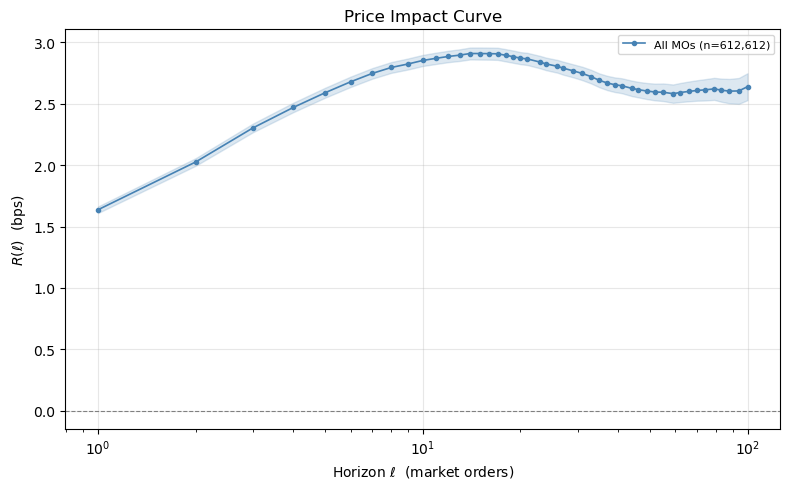

MOs total: 612,612
  walked ticks:    83,131
  no tick walk:    529,481
  R(1)  = +1.636 bps
  R(100) = +2.637 bps


In [3]:
am.price_impact_propagator()

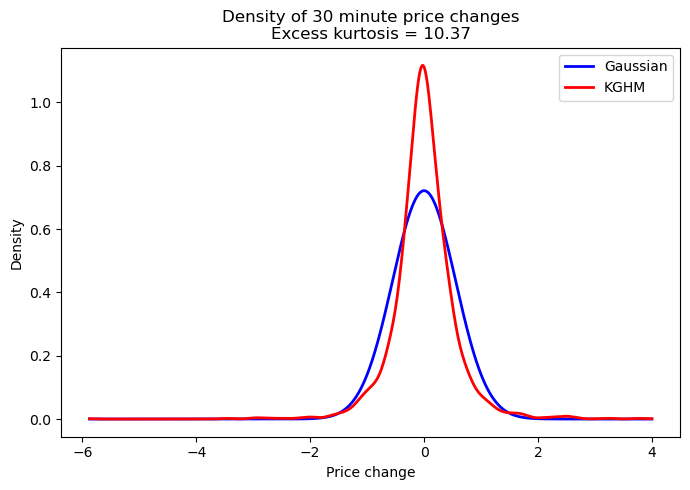

Interval: 30 min  |  n_changes: 3587  |  changes='level'  |  Excess kurtosis: 10.37


In [3]:
am.stylized_fat_tails(label="KGHM")

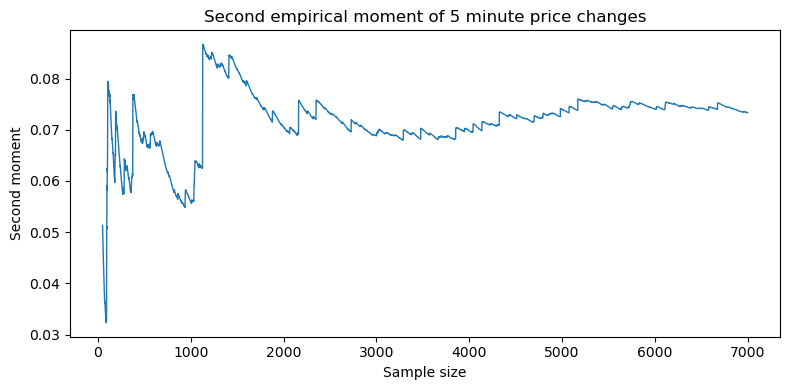

Interval: 5 min  |  n_changes: 21524  |  Final M₂: 0.054028


In [4]:
am.stylized_moment_instability()

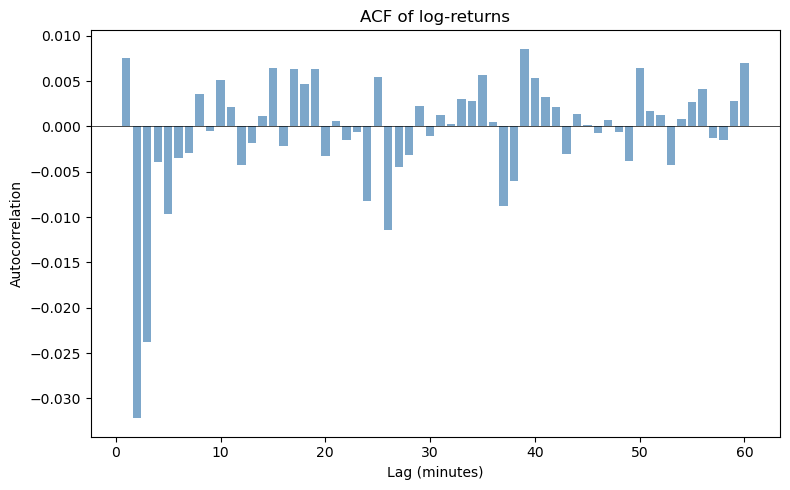

Sampling interval: 1 min
Mean |ACF|: 0.0044  (60 lags)


In [4]:
am.stylized_return_autocorrelation()

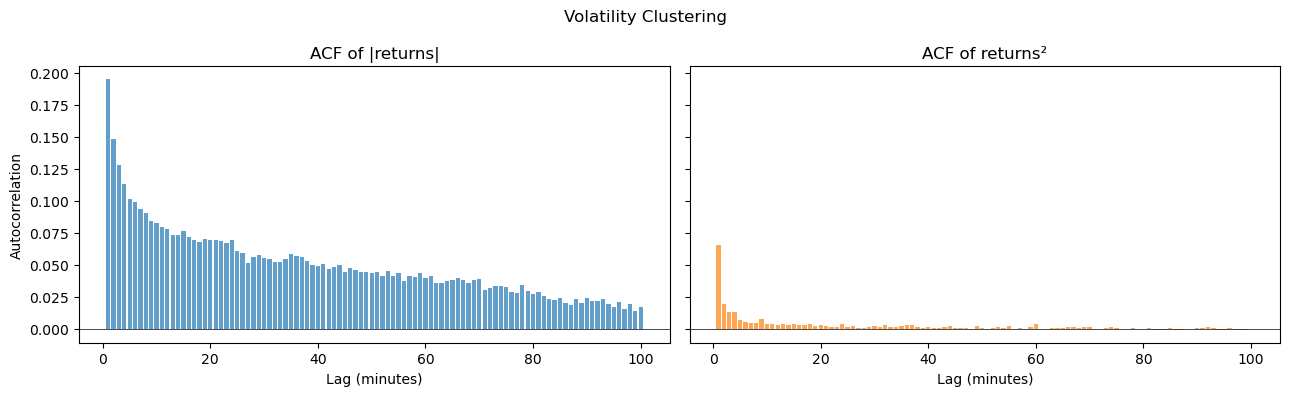

|returns| ACF half-life ≈ 17 min
|returns| ACF(1 min) = 0.1951,  ACF(10 min) = 0.0828


In [5]:
am.stylized_volatility_clustering()

Loading 50 day(s) of mid/MO data (single scan of KGHM_order_flow.sqlite) ...
  50 days, 5,092,705 mid points, 176,209 MOs


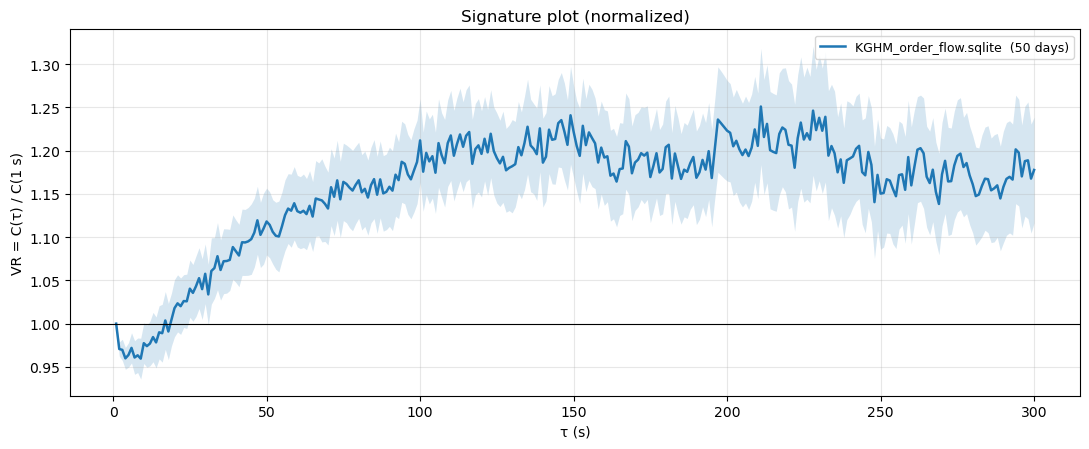

  tau      mean       SE
    3    0.9697   0.0122
    5    0.9638   0.0141
    7    0.9609   0.0194
   10    0.9774   0.0235
   20    1.0179   0.0330
   30    1.0576   0.0345
   50    1.1181   0.0386
   75    1.1638   0.0448
  100    1.2117   0.0482
  150    1.2219   0.0530
  300    1.1776   0.0611
dip min (2-15 s): 0.9596 at τ=9 s


{'taus': array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
         12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
         23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
         34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
         45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
         56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
         67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
         78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
         89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
        100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
        111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
        122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
        133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
        144., 145., 146., 147.

In [10]:
am.signature_plot(n_days=50)

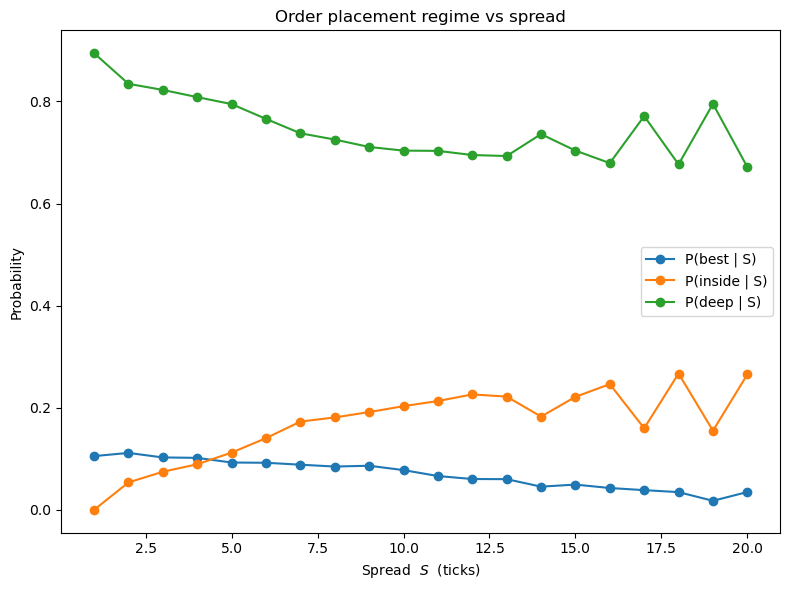

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [0.10536926830343332,
  0.1115900996956773,
  0.10271247331796553,
  0.10190665510562358,
  0.09277806353968335,
  0.09229501771674012,
  0.08852962055462685,
  0.08490338746205368,
  0.08647707486941382,
  0.07792721518987342,
  0.06631360810499655,
  0.06046511627906977,
  0.06017699115044248,
  0.04553846153846154,
  0.04954499494438827,
  0.04284103720405862,
  0.03864478560084701,
  0.03479236812570146,
  0.017783291976840365,
  0.03498293515358362],
 [0.0,
  0.053801852114442786,
  0.07467881056711519,
  0.0893763048202825,
  0.11218144654172738,
  0.1404861505482991,
  0.17296022349950765,
  0.18108225316821663,
  0.1915264074289031,
  0.2031909282700422,
  0.21321667050425974,
  0.22616279069767442,
  0.22194690265486725,
  0.18276923076923077,
  0.22143579373104147,
  0.2463359639233371,
  0.1598729486500794,
  0.2671156004489338,
  0.15508684863523572,
  0.26535836177474403],
 [0.8945854307143924,
  0.

In [4]:
am.probability_vs_spread(max_spread=20)

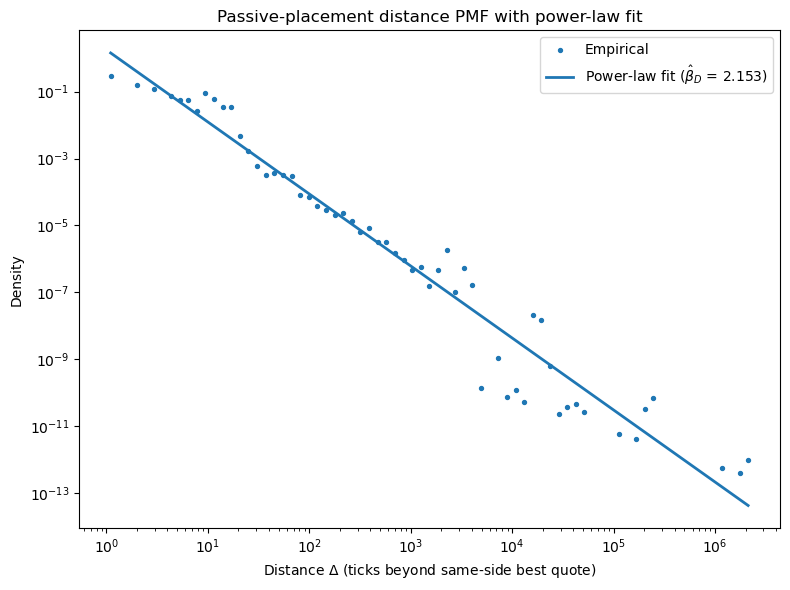

Total passive orders: 7,585,411
β_D = 2.1526,  R² = 0.9546


(2.1526067683050507, 0.9546302178349554)

In [3]:
am.passive_depth_pmf()

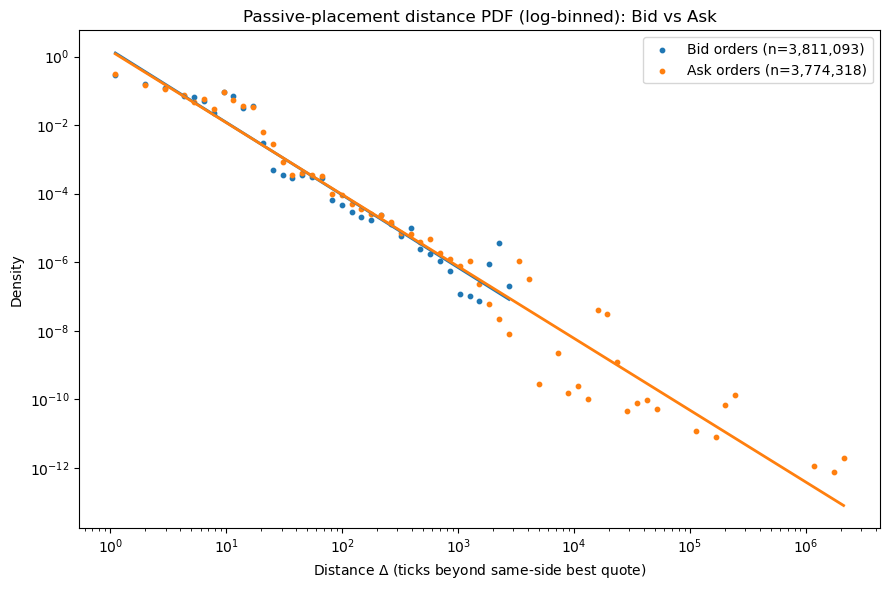

Bid orders: β_D = 2.1169,  R² = 0.9409
Ask orders: β_D = 2.0972,  R² = 0.9542


In [4]:
am.passive_depth_by_side()

Spread = 1: β_D = 2.0044
Spread 2-8: β_D = 2.1223
Spread ≥ 9: β_D = 1.6807


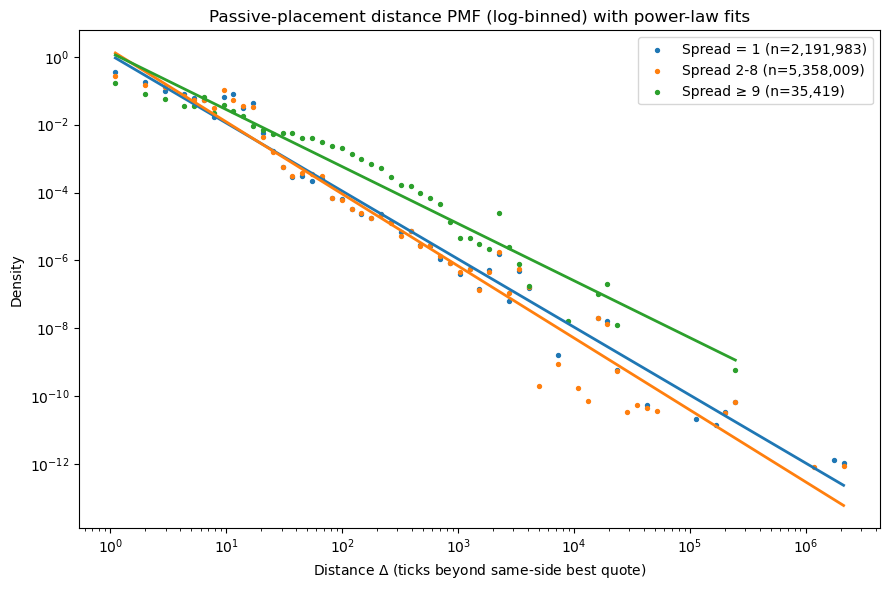

In [6]:
am.passive_depth_by_spread()

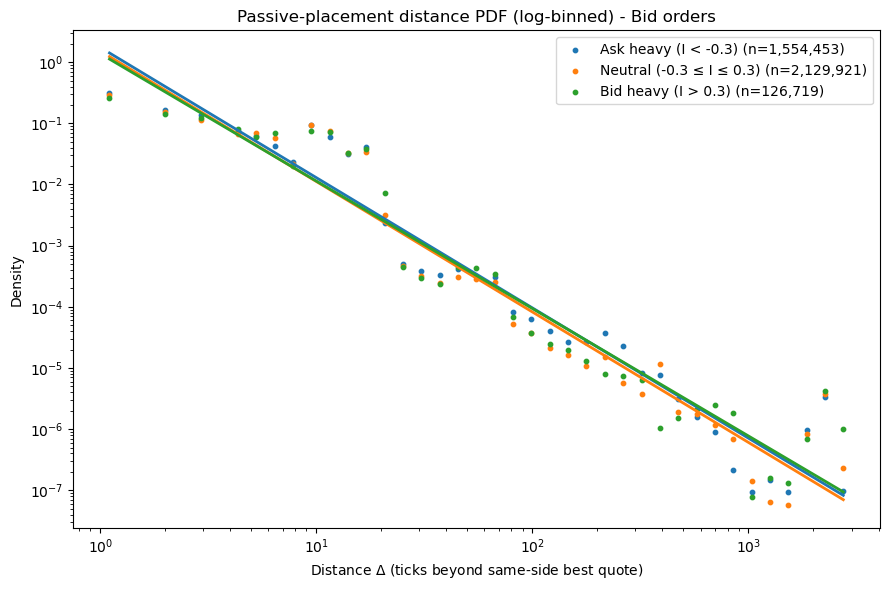

Bid orders | Ask heavy (I < -0.3): β_D = 2.1294,  R² = 0.9434
Bid orders | Neutral (-0.3 ≤ I ≤ 0.3): β_D = 2.1329,  R² = 0.9348
Bid orders | Bid heavy (I > 0.3): β_D = 2.0836,  R² = 0.9249


[('Bid orders',
  'Ask heavy (I < -0.3)',
  2.1294019779311473,
  0.9434274932988271),
 ('Bid orders',
  'Neutral (-0.3 ≤ I ≤ 0.3)',
  2.132894374423475,
  0.9348160140560682),
 ('Bid orders', 'Bid heavy (I > 0.3)', 2.0835683028597103, 0.9249424554971863)]

In [7]:
am.passive_depth_by_imbalance(side="bid")

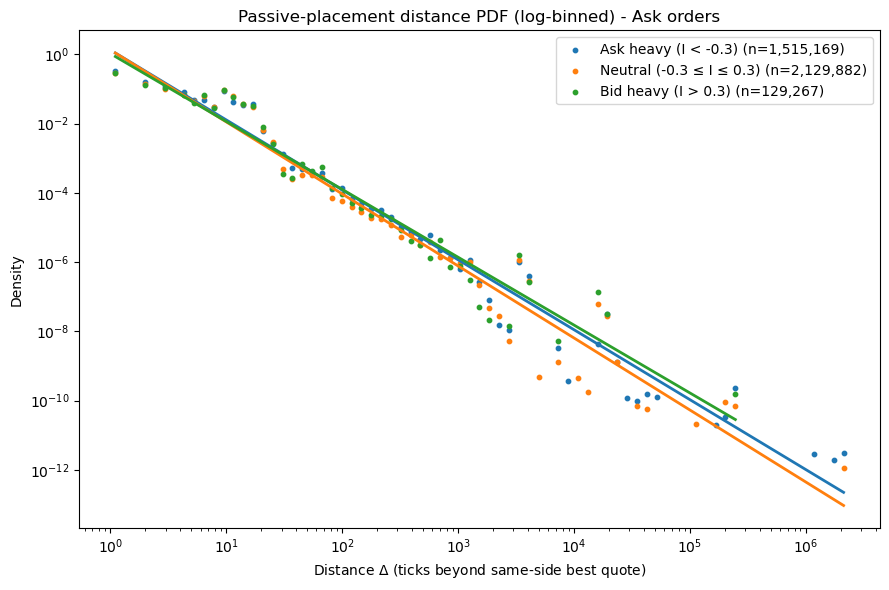

Ask orders | Ask heavy (I < -0.3): β_D = 2.0194,  R² = 0.9684
Ask orders | Neutral (-0.3 ≤ I ≤ 0.3): β_D = 2.0799,  R² = 0.9520
Ask orders | Bid heavy (I > 0.3): β_D = 1.9597,  R² = 0.9398


[('Ask orders', 'Ask heavy (I < -0.3)', 2.019442200780103, 0.9683801774176176),
 ('Ask orders',
  'Neutral (-0.3 ≤ I ≤ 0.3)',
  2.0799472707432103,
  0.9520177711370257),
 ('Ask orders', 'Bid heavy (I > 0.3)', 1.9596883602242638, 0.9397519227931188)]

In [8]:
am.passive_depth_by_imbalance(side="ask")

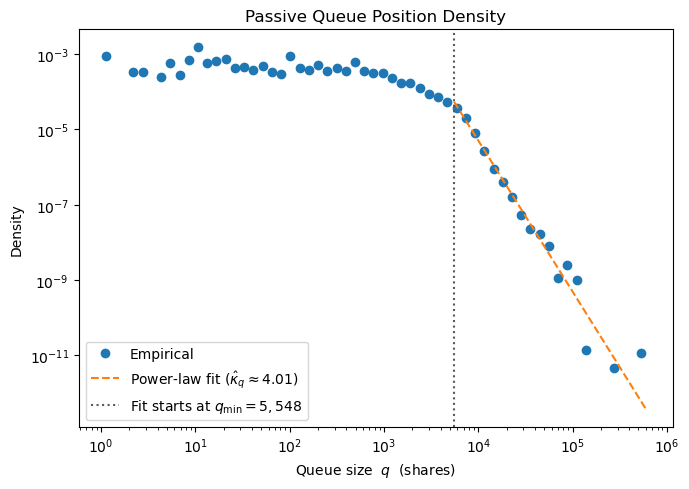

kappa_q = 4.010  (xmin = 5548, tail mass = 10.0%)


(4.009713899653288, 5548.0)

In [3]:
am.queue_passive()

Table-lookup PMFs p[x] for x=1..19 (renormalize over legal x∈{1..S-1} at runtime, then np.random.choice):
  narrow (n=397,886):
    p = [0.803451, 0.153888, 0.04266 , 0.      , 0.      , 0.      , 0.      ,
 0.      , 0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
 0.      , 0.      , 0.      , 0.      , 0.      ]
  medium (n=70,531):
    p = [0.593583, 0.137727, 0.093037, 0.12016 , 0.037558, 0.013909, 0.004027,
 0.      , 0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
 0.      , 0.      , 0.      , 0.      , 0.      ]
  wide (n=8,547):
    p = [0.259389, 0.138879, 0.10179 , 0.094185, 0.075816, 0.0702  , 0.055809,
 0.06435 , 0.038961, 0.037323, 0.016263, 0.016029, 0.008541, 0.007605,
 0.004563, 0.004914, 0.002106, 0.002691, 0.000585]


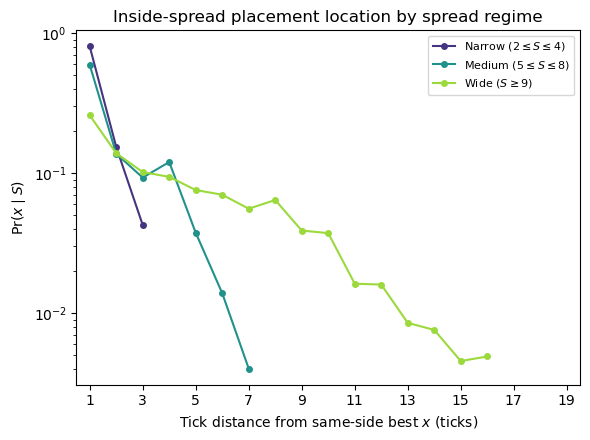

{'narrow': array([0.80345124, 0.1538883 , 0.04266046, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ]),
 'medium': array([0.59358296, 0.13772667, 0.0930371 , 0.12015993, 0.03755795,
        0.01390878, 0.0040266 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ]),
 'wide': array([0.25938926, 0.13887914, 0.1017901 , 0.09418509, 0.07581608,
        0.07020007, 0.05580906, 0.06435006, 0.03896104, 0.03732304,
        0.01626302, 0.01602902, 0.00854101, 0.00760501, 0.004563  ,
        0.004914  , 0.002106  , 0.002691  , 0.000585  ])}

In [3]:
# Absolute-distance cells with fewer than 30 observations are omitted.
am.inside_spread_pmf_by_spread(
    max_spread=20,
    min_count=30,
    show_pooled=False,
)

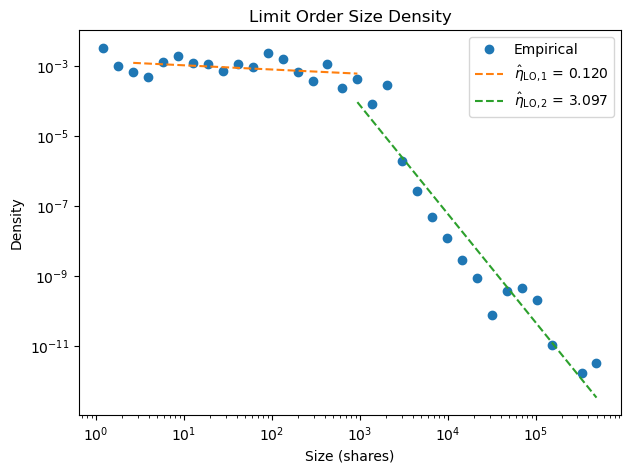

η_LO,1 ≈ 0.120
η_LO,2 ≈ 3.097


In [4]:
am.lo_size_distribution()

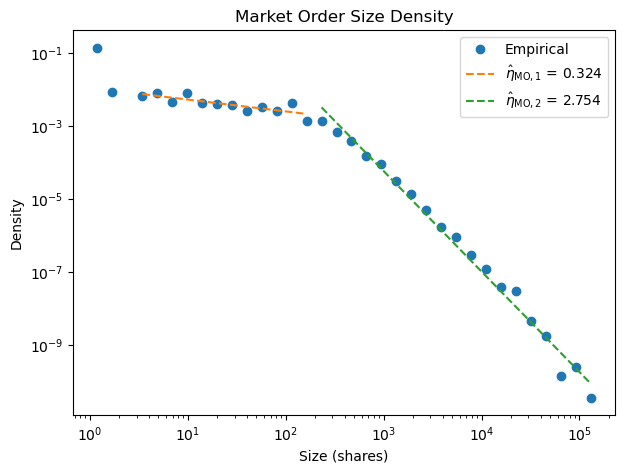

η_MO,1 ≈ 0.324
η_MO,2 ≈ 2.754


In [5]:
am.mo_size_distribution()

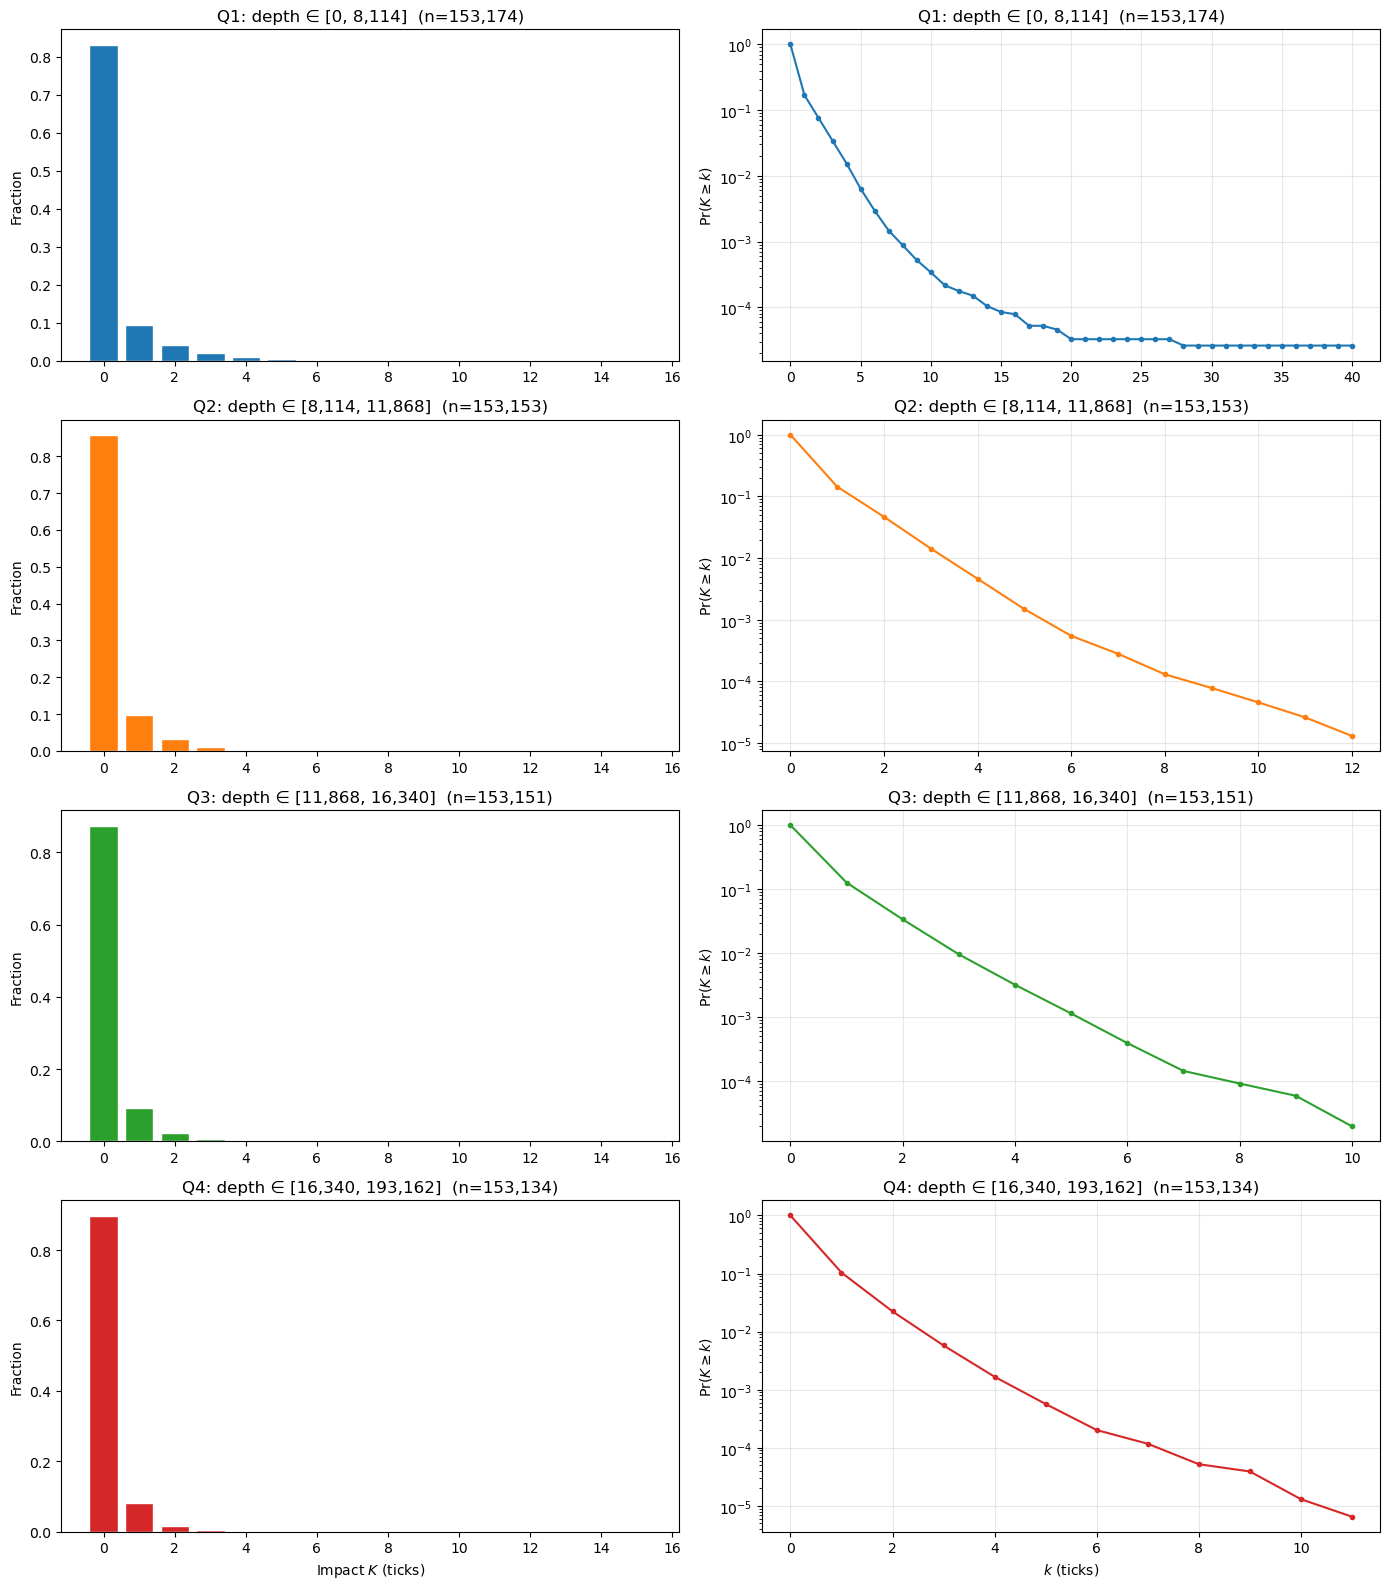


  Quartile         n    mean K    P(>0)     P(≥5)
        Q1   153,174     0.309    16.9%     0.64%
        Q2   153,153     0.212    14.4%     0.15%
        Q3   153,151     0.175    12.6%     0.11%
        Q4   153,134     0.135    10.4%     0.06%


In [3]:
am.price_impact_by_depth()

Streaming P(·|C) done.
  0% (0 events)
  5% (890,914 events)
  10% (1,781,828 events)
  15% (2,672,741 events)
  20% (3,563,655 events)
  25% (4,454,569 events)
  30% (5,345,482 events)
  35% (6,236,396 events)
  40% (7,127,310 events)
  45% (8,018,223 events)
  50% (8,909,137 events)
  55% (9,800,051 events)
  60% (10,690,964 events)
  65% (11,581,878 events)
  70% (12,472,792 events)
  75% (13,363,705 events)
  80% (14,254,619 events)
  85% (15,145,533 events)
  90% (16,036,446 events)
  95% (16,927,360 events)

100% done (17,818,273 events)
  Active orders remaining: 3,593
  Lifetimes collected:     8,742,528
  Queue-position samples:  8,753,087
n_trades = 612,612
P(C) per trade-timestep per order = 0.04233736


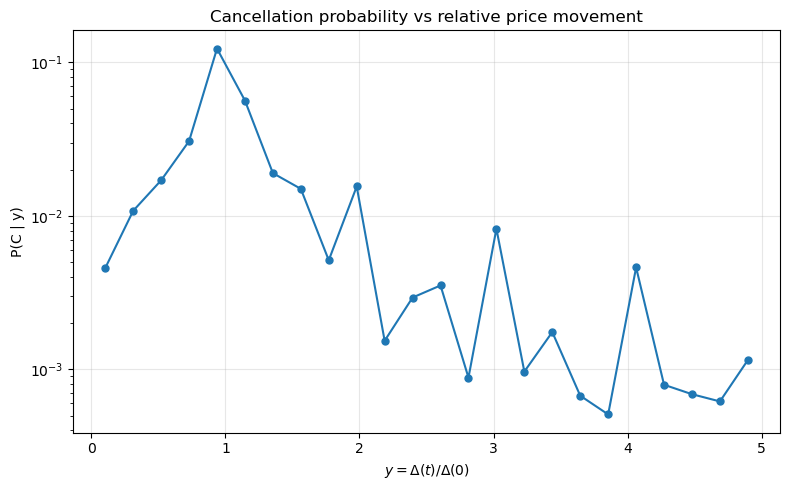

P(C|y) range: [0.0005, 0.1229]


In [4]:
am.cancel_prob_y(log_scale=True)

Streaming P(·|C) done.
  0% (0 events)
  5% (890,914 events)
  10% (1,781,828 events)
  15% (2,672,741 events)
  20% (3,563,655 events)
  25% (4,454,569 events)
  30% (5,345,482 events)
  35% (6,236,396 events)
  40% (7,127,310 events)
  45% (8,018,223 events)
  50% (8,909,137 events)
  55% (9,800,051 events)
  60% (10,690,964 events)
  65% (11,581,878 events)
  70% (12,472,792 events)
  75% (13,363,705 events)
  80% (14,254,619 events)
  85% (15,145,533 events)
  90% (16,036,446 events)
  95% (16,927,360 events)

100% done (17,818,273 events)
  Active orders remaining: 3,593
  Lifetimes collected:     8,742,528
  Queue-position samples:  8,753,087
Queue-position samples: 8,753,087
  Median absolute:   157
  Mean absolute:     248.9
  Median fractional: 0.991
  Mean fractional:   0.970

Fitted Beta(α=17.5600, β=0.5697)


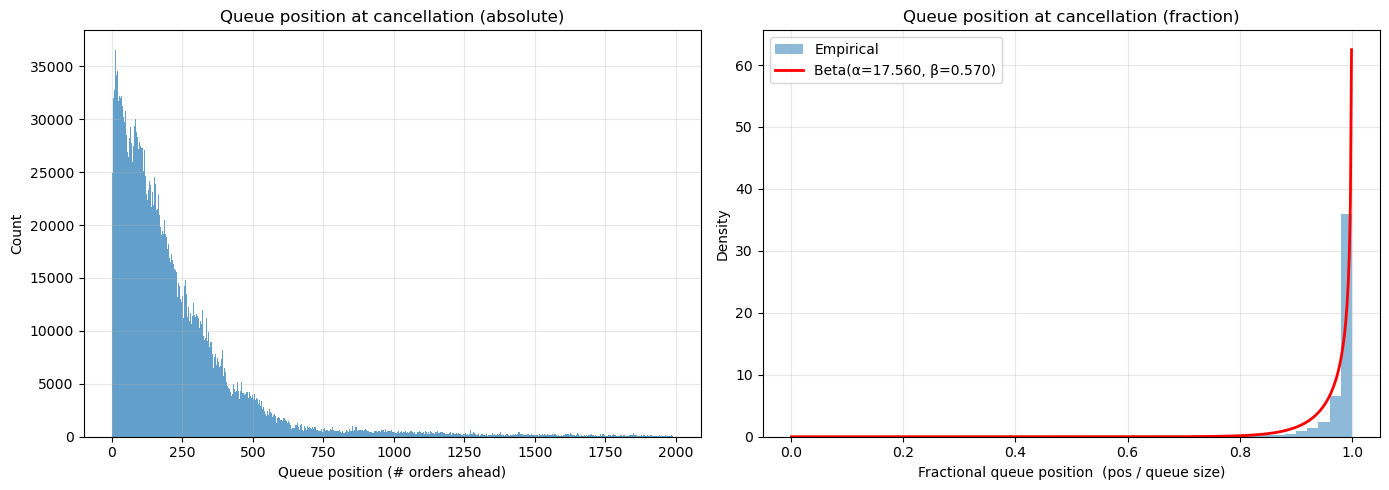

In [4]:
am.cancel_queue_position()